## Предсказываем купит снова или нет в течении месяца

`Это плохая модель, ещё и с протекающими параметрами.`\
Но дня предсказания **общего, группого** оттока/возврата, мы считаем она подойдёт.\
Мы просто хотим показать в интерфейсе общую тенденцию.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from catboost import CatBoostClassifier
from sqlalchemy import create_engine, text
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

print('Необходимые библиотеки загружены.')

Необходимые библиотеки загружены.


In [2]:
# загрузка переменных из .env
load_dotenv()

# получаем токен из окружения
POSTGRES_CONNECTION_URL = os.getenv("POSTGRES_CONNECTION_URL")

try:
    # 1. Загрузка данных
    engine = create_engine(POSTGRES_CONNECTION_URL)

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # engine.dispose()
    print("Connected.")

Connected.


In [2]:
customer_features = pd.read_sql_query(
  f"""SELECT
  cft.customer_unique_id,
  cft.timeline_date,
  cft.city_size,
  cft.city_center_distance_km,
  cft.city_center_level,
  cft.days_after_order,
  cft.days_before_order,
  cft.is_customer_will_order,
  cft.days_before_order < 30 as is_customer_will_month,
-- -- cft.state_density,
  cft.state_income,
--  cft.state_north_south_index,
  cft.last_delivery_distance_km,
--  cft.last_delivery_delay_days,
  cft.last_delivery_cost,
  cft.last_order_cost,
-- -- cft.last_cancelled,
-- -- cft.last_delivered,
  cft.last_review_score,
  cft.last_review_length,
  cft.last_review_match_description,
  cft.last_review_product_state,
  cft.last_review_recommend,
  cft.last_review_sentiment,
  cft.last_review_buy_again,
  cft.last_review_want_leave,
  cft.last_review_unexpected_issues,
  cft.last_review_quality_happy,
  cft.avg_order_interval_days,
  coalesce(cft.main_payment_type, 'not_defined') as main_payment_type,
--  cft.last_order_month,
  cft.last_order_day_of_year,

--  srm.retention_rate_percent,
    srm.weighted_retention_rate,
--  srm.churn_rate_percent,
    srm.weighted_churn_rate,
--  srm.avg_review_score,
--  srm.weighted_avg_review_score,
-- --  srm.review_count,
  srm.percent_null_reviews,
  srm.dispersion_review_score,
  srm.avg_review_message_length,
--  srm.fake_review_probability,
  srm.product_count,
  srm.order_date_variance,

  p.product_name_lenght,
  p.product_description_lenght,
  p.product_photos_qty,
--  p.product_weight_g,
--  p.product_length_cm,
--  p.product_height_cm,
--  p.product_width_cm,
  --prm.weighted_retention_rate as product_weighted_retention_rate,
  --prm.weighted_churn_rate as product_weighted_churn_rate
  coalesce(abcxyz.category_adc, 'C') as category_adc,
  coalesce(abcxyz.category_xyz, 'Z') as category_xyz

FROM customer_features_timeline2 cft
left join orders o on o.order_id ::uuid=cft.order_id 
--full join orders_items oi on oi.order_id =o.order_id
inner join orders_items oi on oi.order_id =o.order_id
left join seller_retention_metrics srm on srm.seller_id =oi.seller_id
left join products p on p.product_id =oi.product_id
left join product_retention_metrics prm on prm.product_id =oi.product_id
left join public.analysis_abc_2_xyz abcxyz on abcxyz.product_category_name =p.product_category_name

where cft.timeline_date <>'2018-05-02' and cft.id is not null""", engine)

In [3]:
print("Test IDs already exist in the database.  Loading from the table.")
test_customer_ids_df = pd.read_sql_query("SELECT customer_unique_id FROM customer_test_ids", engine)
test_customer_ids = test_customer_ids_df['customer_unique_id'].tolist()
if not len(test_customer_ids):
  raise Exception('Таблица тестовых клиентов не заполнена')

Test IDs already exist in the database.  Loading from the table.


## Пробуем обучить модель

- Используем CatBoost для бинарной классификации.
- Разделяем данные по времени (train до 2018-02-01, test после).
- Учитываем дисбаланс классов (3% повторных заказов).

In [4]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns


# Убедимся, что timeline_date — datetime
customer_features['timeline_date'] = pd.to_datetime(customer_features['timeline_date'])

# Выбираем дату-разделитель
split_date = pd.to_datetime("2018-02-01")

# Делим по дате и customer_unique_id
train_df = customer_features[
    (~customer_features['customer_unique_id'].isin(test_customer_ids)) &
    (customer_features['timeline_date'] < split_date)
]

test_df = customer_features[
    (customer_features['customer_unique_id'].isin(test_customer_ids)) &
    (customer_features['timeline_date'] >= split_date)
]

# Убираем object/string и нечисловые данные
# Список категориальных признаков, которые НЕ нужно исключать
cat_features = ['main_payment_type']
cols_to_exclude = [
    col for col in train_df.select_dtypes(include=['object', 'string']).columns
    if col not in cat_features
]
train_df = train_df.drop(columns=cols_to_exclude)
test_df = test_df.drop(columns=cols_to_exclude)

# X и y
drop_cols = ['is_customer_will_order', 'is_customer_will_month', 'days_before_order', 'timeline_date']
X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['is_customer_will_month']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['is_customer_will_month']

# NaN → среднее
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test = X_test.fillna(X_train.mean(numeric_only=True))  # подгонка под train

# Веса классов
sample_weights = compute_sample_weight('balanced', y_train)


0:	learn: 0.7484293	test: 0.0816555	best: 0.0816555 (0)	total: 278ms	remaining: 7m 24s
200:	learn: 0.9834061	test: 0.0251046	best: 0.1033493 (36)	total: 40.9s	remaining: 4m 44s
400:	learn: 0.9936062	test: 0.0425532	best: 0.1033493 (36)	total: 1m 22s	remaining: 4m 6s
600:	learn: 0.9964759	test: 0.0459770	best: 0.1033493 (36)	total: 2m 4s	remaining: 3m 26s
800:	learn: 0.9978905	test: 0.0359281	best: 0.1033493 (36)	total: 2m 45s	remaining: 2m 45s
1000:	learn: 0.9988048	test: 0.0355030	best: 0.1033493 (36)	total: 3m 28s	remaining: 2m 4s
1200:	learn: 0.9991233	test: 0.0355030	best: 0.1033493 (36)	total: 4m 2s	remaining: 1m 20s
1400:	learn: 0.9993489	test: 0.0355030	best: 0.1033493 (36)	total: 4m 42s	remaining: 40.1s
1599:	learn: 0.9994685	test: 0.0355030	best: 0.1033493 (36)	total: 5m 15s	remaining: 0us

bestTest = 0.1033492823
bestIteration = 36

Shrink model to first 37 iterations.
              precision    recall  f1-score   support

       False       0.98      0.86      0.92      5894

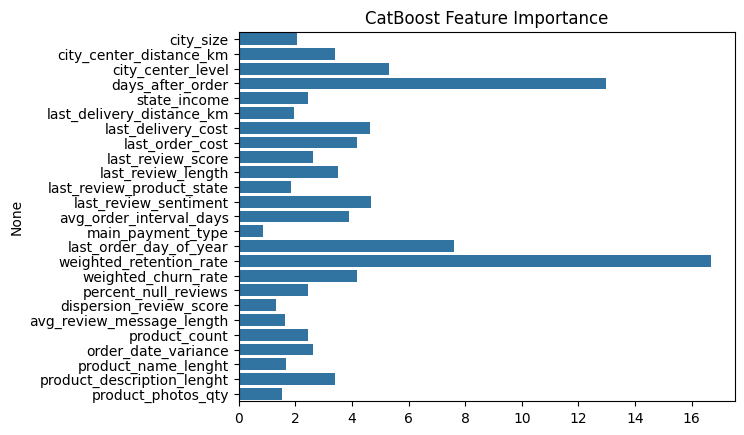

In [5]:

model = CatBoostClassifier(
    iterations=1600,
    learning_rate=0.06777903832127262,
    depth=10,
    l2_leaf_reg=9.0490576545471,
    random_strength=0.7961766953481294,
    eval_metric='F1',
    verbose=200,
    random_seed=42,
    cat_features=cat_features
)

model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# Предсказания и отчёт
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
importances = model.get_feature_importance()
sns.barplot(x=importances, y=X_train.columns)
plt.title('CatBoost Feature Importance')
plt.show()

In [6]:
importances = model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({
    'feature': features,
    'importance_%': (importances / importances.sum()) * 100
}).sort_values(by='importance_%', ascending=False)

print(importance_df.to_string(index=False, float_format='%.2f'))

                   feature  importance_%
   weighted_retention_rate         16.67
          days_after_order         12.98
    last_order_day_of_year          7.61
         city_center_level          5.30
     last_review_sentiment          4.66
        last_delivery_cost          4.66
           last_order_cost          4.19
       weighted_churn_rate          4.19
   avg_order_interval_days          3.90
        last_review_length          3.50
product_description_lenght          3.41
   city_center_distance_km          3.40
         last_review_score          2.63
       order_date_variance          2.62
             product_count          2.46
              state_income          2.46
      percent_null_reviews          2.45
                 city_size          2.06
 last_delivery_distance_km          1.94
 last_review_product_state          1.87
       product_name_lenght          1.68
 avg_review_message_length          1.63
        product_photos_qty          1.55
   dispersion_re

### Сохраняем модель для дельнейшего использования

In [7]:
model.save_model("ml-models/TimeMachine month.cbm")

### Пример последующей загрузки и использования модели

In [8]:
import numpy as np
from catboost import CatBoostClassifier

model = CatBoostClassifier()
model.load_model("ml-models/TimeMachine month.cbm")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.98      0.86      0.92      5894
        True       0.06      0.35      0.10       156

    accuracy                           0.85      6050
   macro avg       0.52      0.60      0.51      6050
weighted avg       0.96      0.85      0.89      6050



In [32]:
sample = X_test.sample(1)

pred_class = model.predict(sample)[0]
pred_proba = model.predict_proba(sample)[0][1]  # вероятность класса True

print("Класс:", bool(pred_class))
print("Вероятность повторной покупки:", f'{(100 * pred_proba):.2f}%')

Класс: False
Вероятность повторной покупки: 33.80%
